   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

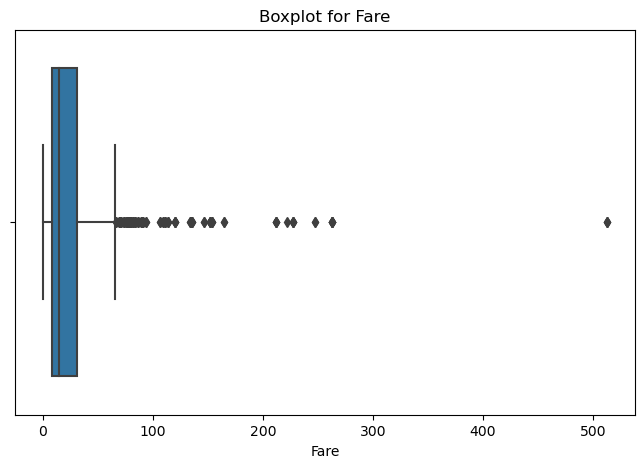

Dataset after removing outliers:
(775, 12)


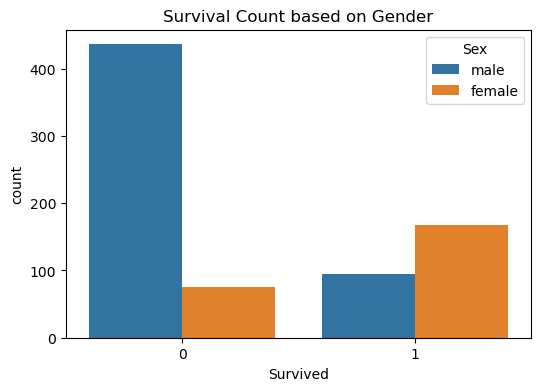

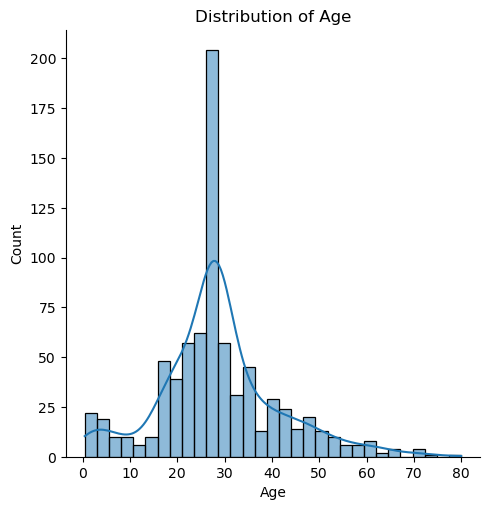

Cross Tabulation:
Survived    0    1
Sex               
female     76  168
male      436   95


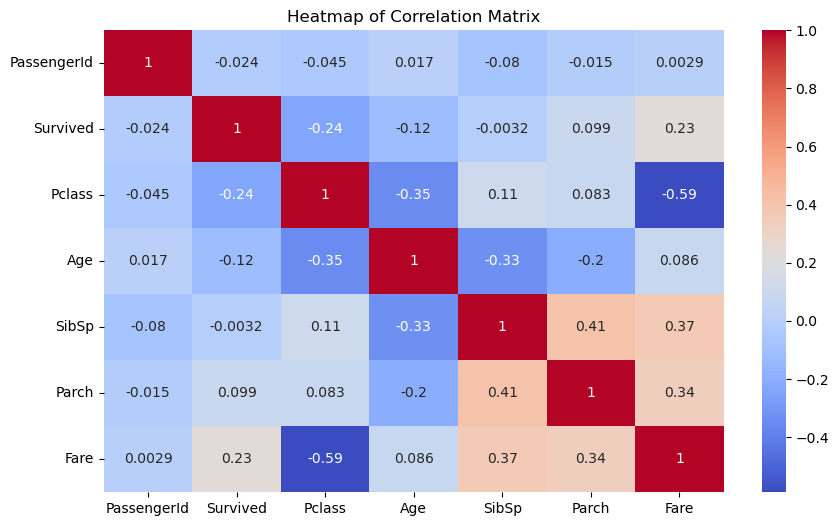

In [3]:
# Exploratory Data Analysis on Titanic Dataset

# STEP 1: Import required packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("titanic_dataset.csv")

# Display first 5 rows
print(df.head())

# Display dataset information
print(df.info())


# STEP 2: Replace null values using mean/median/mode

# Age -> median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fare -> mean
df['Fare'].fillna(df['Fare'].mean(), inplace=True)

# Embarked -> mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Check null values
print(df.isnull().sum())


# STEP 3: Use boxplot to analyze outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot for Fare")
plt.show()


# STEP 4: Remove outliers using IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df['Fare'] > lower_limit) & (df['Fare'] <= upper_limit)]

print("Dataset after removing outliers:")
print(df.shape)


# STEP 5: Countplot for categorical data
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival Count based on Gender")
plt.show()


# STEP 6: Displot for univariate distribution
sns.displot(df['Age'], kde=True)
plt.title("Distribution of Age")
plt.show()


# STEP 7: Cross Tabulation
cross_tab = pd.crosstab(df['Sex'], df['Survived'])
print("Cross Tabulation:")
print(cross_tab)


# STEP 8: Heatmap for relationship analysis
plt.figure(figsize=(10,6))
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Heatmap of Correlation Matrix")
plt.show()